# EDA — French Motor Third-Party Liability (MTPL) Claims

Exploratory only — this notebook re-derives the cleaned dataset for inspection.
Production cleaning logic lives in `src/data/merge_clean.py`; nothing here is
imported by the modeling pipeline.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load import fetch_frequency_data, fetch_severity_data
from src.data.merge_clean import build_merged_clean_dataset
from src.config import REPORTS_FIGURES_DIR

sns.set_theme(style="whitegrid")

freq = fetch_frequency_data()
sev = fetch_severity_data()
df, cleaning_summary = build_merged_clean_dataset(freq, sev)
cleaning_summary

{'exposure_capped_rows': 1224,
 'exposure_floored_rows': 3105,
 'claimnb_capped_rows': 9,
 'zero_claimnb_nonzero_amount_rows': 0,
 'nonzero_claimnb_zero_amount_rows': 9116,
 'top_0.1pct_severity_threshold': 181252.22200000368,
 'n_rows': 678013,
 'claim_rate': 0.05023502499214617}

## Cleaning summary

- 1,224 rows had Exposure > 1.0 (capped) and 3,105 had Exposure < ~1 day (floored) —
  both are small fractions of 678k rows, consistent with data-entry noise rather
  than a systematic issue.
- Only 9 rows had ClaimNb > 4 (capped) — genuinely rare outliers.
- 0 rows had ClaimNb == 0 with a nonzero claim amount — the two tables agree cleanly
  in that direction.
- **9,116 of 34,060 claiming policies (~27%) have no matching severity record at
  all.** This is a known artifact of how freMTPL2freq/sev were extracted (see
  comment in `src/data/merge_clean.py`), not a join bug — verified by checking
  IDpol overlap directly. These rows are legitimate `ClaimNb>0, ClaimAmountTotal=0`
  rows and simply don't participate in severity-model training.

## 1. Claim frequency distribution

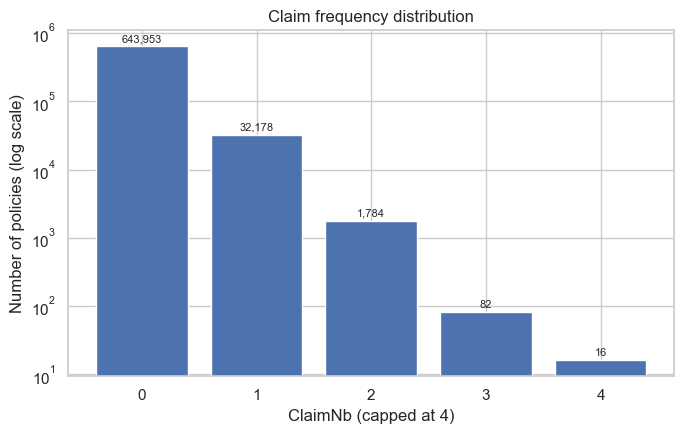

Overall claim rate: 0.05023502499214617


In [2]:
fig, ax = plt.subplots(figsize=(7, 4.5))
counts = df["ClaimNb"].value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, color="#4C72B0")
ax.set_yscale("log")
ax.set_xlabel("ClaimNb (capped at 4)")
ax.set_ylabel("Number of policies (log scale)")
ax.set_title("Claim frequency distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v * 1.15, f"{v:,}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS_FIGURES_DIR / "claim_frequency_distribution.png", dpi=150)
plt.show()
print("Overall claim rate:", df["HasClaim"].mean())

**Interpretation:** ~95% of policy-years have zero claims; the claim rate is
~5.0%. This is a severe class imbalance for the frequency classifier — it's the
direct motivation for using `scale_pos_weight` (computed as `n_negative/n_positive`
on the training split) rather than treating this as a balanced classification
problem, and for evaluating with PR-AUC rather than accuracy (a model predicting
"no claim" for everyone would already be 95% accurate).

## 2. Severity distribution — raw vs log

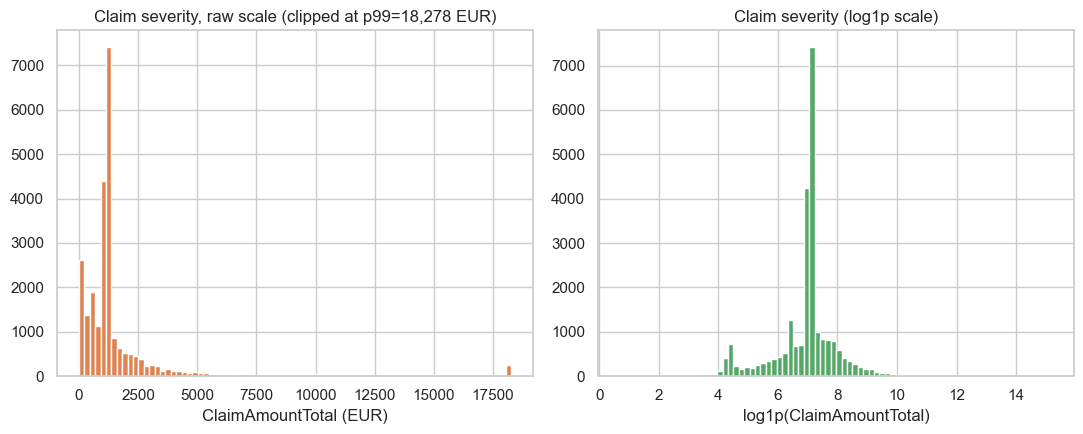

Raw skew: 106.14445920005151
Log1p skew: -0.5124529453427152
Max claim: 4075400.56


In [3]:
claims = df.loc[df["ClaimAmountTotal"] > 0, "ClaimAmountTotal"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
# raw-scale histogram is unreadable without clipping the DISPLAY range: a handful
# of claims run into the millions and crush every other bar flat. Clip at p99 for
# the plot only (not the underlying data) - the caption still reports the true max.
p99 = claims.quantile(0.99)
axes[0].hist(claims.clip(upper=p99), bins=80, color="#DD8452")
axes[0].set_title(f"Claim severity, raw scale (clipped at p99={p99:,.0f} EUR)")
axes[0].set_xlabel("ClaimAmountTotal (EUR)")
axes[1].hist(np.log1p(claims), bins=80, color="#55A868")
axes[1].set_title("Claim severity (log1p scale)")
axes[1].set_xlabel("log1p(ClaimAmountTotal)")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES_DIR / "severity_distribution.png", dpi=150)
plt.show()
print("Raw skew:", claims.skew())
print("Log1p skew:", np.log1p(claims).skew())
print("Max claim:", claims.max())

**Interpretation:** raw severity has skew ≈ 106 — a handful of very large claims
(the tail runs past €180k for the top 0.1%) dominate the raw distribution's shape.
`log1p` transformation brings skew down to about -0.5, which is close enough to
symmetric that squared-error loss on the log scale is a reasonable fit objective.
This is the basis for the severity model's log-transform choice over `reg:tweedie`
(see `src/models/severity.py` for the full reasoning — Tweedie is more suited to
jointly modeling the zero-mass and the continuous tail in one model, which isn't
needed here since frequency and severity are already separated).

## 3. Exposure distribution

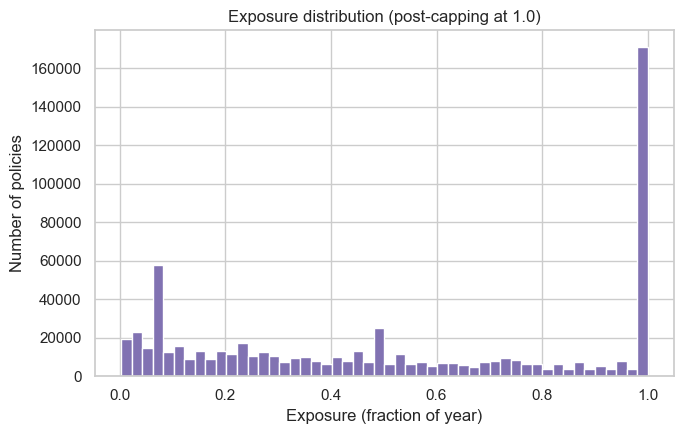

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df["Exposure"], bins=50, color="#8172B2")
ax.set_xlabel("Exposure (fraction of year)")
ax.set_ylabel("Number of policies")
ax.set_title("Exposure distribution (post-capping at 1.0)")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES_DIR / "exposure_distribution.png", dpi=150)
plt.show()

**Interpretation:** exposure is bimodal — a large spike at 1.0 (full-year
policies) and a roughly uniform spread of partial-year policies below it (new
policies, mid-year cancellations). Before capping, 1,224 rows exceeded 1.0
(data-entry artifacts, since a policy-year can't exceed one year of exposure by
definition); after capping, the spike at 1.0 is the honest reflection of a full
policy-year.

## 4. Correlation with claim outcome

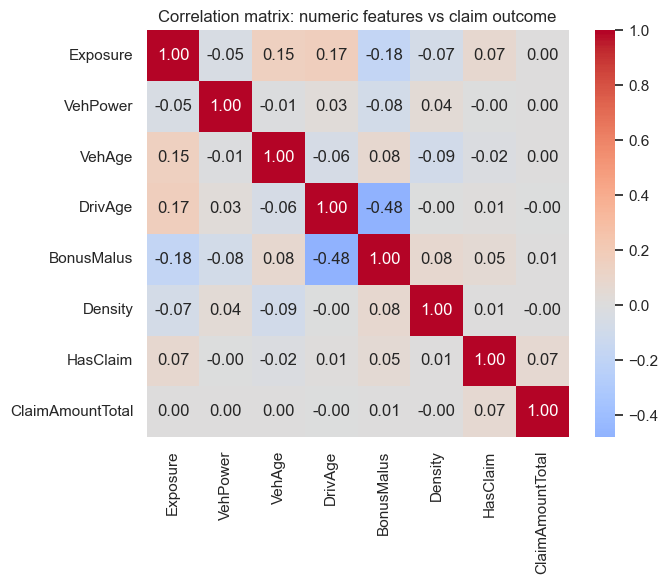

In [5]:
numeric_cols = ["Exposure", "VehPower", "VehAge", "DrivAge", "BonusMalus", "Density",
                 "HasClaim", "ClaimAmountTotal"]
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix: numeric features vs claim outcome")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES_DIR / "correlation_heatmap.png", dpi=150)
plt.show()

**Interpretation:** every linear correlation with `HasClaim` and
`ClaimAmountTotal` is weak (|r| < 0.08). This is expected, not a red flag — Pearson
correlation only captures linear, marginal relationships, while actual claim risk
in this data is driven by interactions (e.g. a young driver with a high-power car
in a dense urban area) that a correlation matrix can't surface. This is the
motivation for a tree-based model (XGBoost) over a linear GLM baseline: trees
capture these interactions natively via splits, whereas a GLM would need them
hand-engineered as explicit interaction terms.

The strongest single signals are `Exposure` and `BonusMalus` with `HasClaim`
(r ≈ 0.07 and 0.05) — both make actuarial sense: more exposure time means more
opportunity to claim, and BonusMalus is literally France's own driving-history risk
score, so a positive correlation with claims is exactly what should be true if the
score is doing its job.